In [1]:
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.chrome.options import Options
import requests
from bs4 import BeautifulSoup
import time
import os
from dotenv import load_dotenv
import pandas as pd
import numpy as np

In [2]:
data = []
data.append({
    '숙소명':'힐튼 경주',
    '평점':9.4,
    '평가수':'10,361',
    '금액':'202,400'
})
data.append({
    '숙소명':'오소한옥스테이',
    '평점':9.8,
    '평가수':'154',
    '금액':'325,000'
})
data.append({
    '숙소명':'소노캄 경주',
    '평점':8.8,
    '평가수':'872',
    '금액':'368,000'
})

In [3]:
df = pd.DataFrame(data)
df

,숙소명,평점,평가수,금액
0,힐튼 경주,9.4,"10,361","202,400"
1,오소한옥스테이,9.8,154,"325,000"
2,소노캄 경주,8.8,872,"368,000"


In [4]:
# # 2-2. selenium : 자동화 도구 - 스크롤 사용
# url = "https://www.yeogi.com/domestic-accommodations?keyword=%EA%B2%BD%EC%A3%BC&personal=2&checkIn=2026-10-08&checkOut=2026-10-09&category=2&sortType=RECOMMEND"
# options = Options()
# options.add_experimental_option("excludeSwitches", ["enable-automation"])
# options.add_experimental_option("useAutomationExtension", False)
# options.add_argument("--disable-blink-features=AutomationControlled")
# browser = webdriver.Chrome(options=options)
# browser.maximize_window() # 화면 최대창 확대
# browser.get(url)
# time.sleep(2)

# # 현재 스크롤 높이 가져옴
# prev_height = browser.execute_script("return document.body.scrollHeight")

# while True:
#     # 스크롤 높이 출력
#     print('높이 : ',prev_height)
#     # 스크롤 내리기
#     browser.execute_script("window.scrollTo(0,document.body.scrollHeight)")
#     time.sleep(2)
#     # 스크롤이 추가 되었는지 확인
#     next_height = browser.execute_script("return document.body.scrollHeight")
#     if prev_height == next_height:
#         break
#     prev_height = next_height

# # # 파일저장
# soup = BeautifulSoup(browser.page_source,'lxml')
# with open('file/yeogi01.html','w',encoding='utf-8') as f:
#     f.write(soup.prettify())

# 파일 BeautifulSoup변환
with open('file/yeogi01.html','r',encoding='utf-8') as f:
    soup = BeautifulSoup(f,'lxml')

In [5]:
data = []
y_ul = soup.find('ul',{'class':'css-y5z6rw'})
lis = y_ul.find_all('li',{'class':'gc-thumbnail-type-seller-card-wrapper css-13wylk3'})

In [6]:
rate_numss = lis[3].find('span',{'class':'css-144z61f'}).get_text().strip()
rate_nums = rate_numss.replace(' ','')[:-5]
rate_num = int(rate_nums.replace(',',''))  # 데이터가 없는게 존재함.
rate_num
# rate_num = rate_nums.replace(",","")

3003

In [7]:
y_ul = soup.find('ul',{'class':'css-y5z6rw'})
lis = y_ul.find_all('li',{'class':'gc-thumbnail-type-seller-card-wrapper css-13wylk3'})

data = []
y_ul = soup.find('ul',{'class':'css-y5z6rw'})
lis = y_ul.find_all('li',{'class':'gc-thumbnail-type-seller-card-wrapper css-13wylk3'})

title=None
rating=None
rate_num=None
price=None
for li in lis:
    try:
        title = li.find('h3',{'class':'gc-thumbnail-type-seller-card-title css-1gsfgy5'}).get_text().strip()
        rating = li.find('span',{'class':'css-ry30z7'}).get_text().strip()
        rate_numss = li.find('span',{'class':'css-144z61f'}).get_text().strip()
        rate_nums = rate_numss.replace(' ','')[:-5]
        rate_num = rate_nums.replace(",","")
        price = li.find('span',{'class':'css-1llao6q'}).get_text().strip()
        price = int(price.replace(",","").strip())
    except:
        pass
    data.append({
        '숙소명':title,
        '평점':float(rating),
        '평가수':rate_num,
        '금액':price
    })

In [8]:
df = pd.DataFrame(data)
df

,숙소명,평점,평가수,금액
0,힐튼 경주,9.4,10361,202400
1,오소한옥스테이,9.8,154,325000
2,소노캄 경주,8.8,872,368000
3,라한셀렉트 경주,9.4,3003,388050
4,소노벨 경주 감포,9.1,2295,105000
5,경주시티호텔,9.7,294,303600
6,경주 코모도호텔,9.0,1462,164680
7,이제 경주,9.5,778,325500
8,경주 코오롱호텔,8.0,644,113170
9,란타나호텔 경주불국사점,10.0,8,89000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   숙소명     59 non-null     str    
 1   평점      59 non-null     float64
 2   평가수     59 non-null     str    
 3   금액      59 non-null     int64  
dtypes: float64(1), int64(1), str(2)
memory usage: 2.0 KB


In [10]:
def cal(x):
    if x != '':
        return int(x)
    return 0
df['평가수'] = df['평가수'].apply(cal)
df

,숙소명,평점,평가수,금액
0,힐튼 경주,9.4,10361,202400
1,오소한옥스테이,9.8,154,325000
2,소노캄 경주,8.8,872,368000
3,라한셀렉트 경주,9.4,3003,388050
4,소노벨 경주 감포,9.1,2295,105000
5,경주시티호텔,9.7,294,303600
6,경주 코모도호텔,9.0,1462,164680
7,이제 경주,9.5,778,325500
8,경주 코오롱호텔,8.0,644,113170
9,란타나호텔 경주불국사점,10.0,8,89000


In [11]:
df.fillna(0)

,숙소명,평점,평가수,금액
0,힐튼 경주,9.4,10361,202400
1,오소한옥스테이,9.8,154,325000
2,소노캄 경주,8.8,872,368000
3,라한셀렉트 경주,9.4,3003,388050
4,소노벨 경주 감포,9.1,2295,105000
5,경주시티호텔,9.7,294,303600
6,경주 코모도호텔,9.0,1462,164680
7,이제 경주,9.5,778,325500
8,경주 코오롱호텔,8.0,644,113170
9,란타나호텔 경주불국사점,10.0,8,89000


In [12]:
# 숙소명, 금액 막대그래프 출력

In [13]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['axes.unicode_minus'] = False  # -부호 처리
matplotlib.rcParams['font.family'] = 'Malgun Gothic'  # 한글처리 : 윈도우 맑은고딕 저장
matplotlib.rcParams['font.size'] = 15   # 전체 글자폰튼크기 조정
# matplotlib.rcParams['font.family'] = 'AppleGothic'    # 맥컴 애플고딕 저장

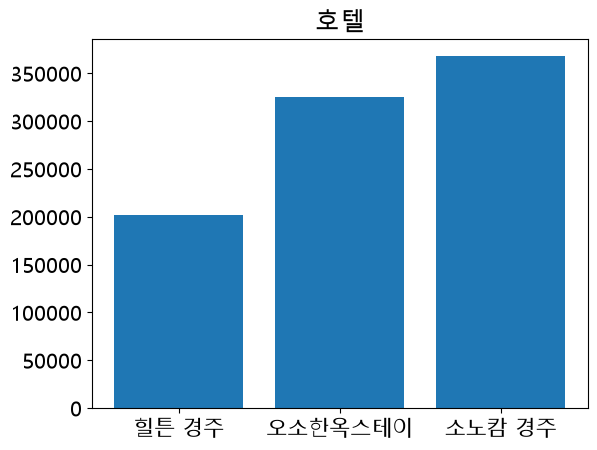

In [14]:
x = df['숙소명'].head(3)
y = df['금액'].head(3)

plt.bar(x,y)
plt.title('호텔')
# plt.yticks([0,10000,20000,30000,40000])
plt.show()